# dane nieustruktyryzowane

Dane nieustrukturyzowane to dane, które nie są w żaden sposób uporządkowane, takie jak:

- obrazy,
- teksty,
- dźwięki,
- wideo.
  
Niezależnie od typu, wszystko przetwarzamy w tensorach (macierzach wielowymiarowych). To może prowadzić do chęci wykorzystania modeli ML i sieci neuronowych do analizy danych nieustrukturyzowanych.

![](../img/data.png)

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid", palette="husl")


# 2-dim picture 28 x 28 pixel
picture_2d = np.random.uniform(size=(28,28))
picture_2d[0:5,0:5]

array([[0.87034958, 0.16073778, 0.84272754, 0.60199508, 0.15423195],
       [0.44907861, 0.73598713, 0.39411018, 0.62567532, 0.61906615],
       [0.03391947, 0.32878753, 0.24041941, 0.92752844, 0.84307137],
       [0.67095923, 0.45683719, 0.4618619 , 0.42645623, 0.60712762],
       [0.46078787, 0.07278108, 0.22462421, 0.94541969, 0.30833405]])

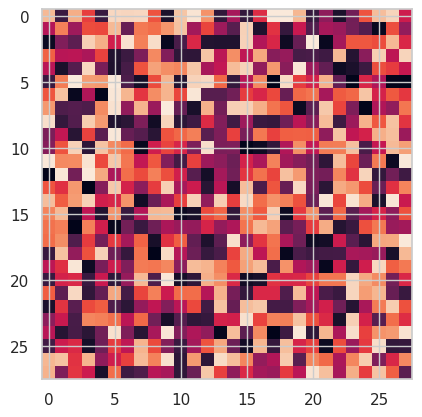

In [2]:
plt.imshow(picture_2d, interpolation='nearest')
plt.show()

# pretrenowane modele klasyfikujące

In [3]:
import requests

url = 'https://pytorch.tips/coffee'
fpath = 'coffee.jpg'

# Dodajemy nagłówek udający prawdziwą przeglądarkę
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

try:
    response = requests.get(url, headers=headers)
    response.raise_for_status()  # Rzuci błąd, jeśli strona nie działa (np. 404 lub 403)
    
    # Zapisujemy pobraną zawartość do pliku
    with open(fpath, 'wb') as f:
        f.write(response.content)
    print("Obrazek pobrany pomyślnie!")
    
except requests.exceptions.RequestException as e:
    print(f"Błąd podczas pobierania: {e}")

Obrazek pobrany pomyślnie!


In [4]:
import matplotlib.pyplot as plt
from PIL import Image # pillow library

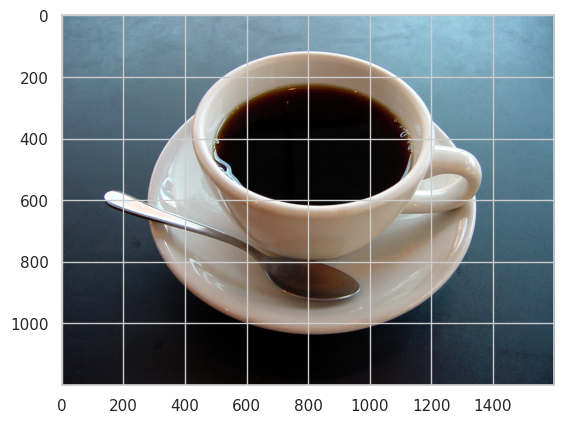

In [5]:
img = Image.open('coffee.jpg')
plt.imshow(img)

In [7]:
#!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

In [8]:
import torch
from torchvision import transforms

In [9]:
from torchvision import models

models.list_models()[:5]

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny']

Odrobinę zmienimy własności obrazka 

In [10]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize( 
    mean = [0.485, 0.456, 0.406],
    std = [0.229, 0.224,0.225])
])

In [11]:
img_tensor = transform(img)

Sprawdzmy rozmiary


In [12]:
type(img_tensor), img_tensor.shape

(torch.Tensor, torch.Size([3, 224, 224]))

In [13]:
# utworzenie batch size - dodatkowego wymiaru (na inne obrazki)
batch = img_tensor.unsqueeze(0)
batch.shape

torch.Size([1, 3, 224, 224])

Załadujmy gotowy model 

In [14]:
alexnet = models.alexnet('weights=AlexNet_Weights.DEFAULT')

/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/jovyan/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [02:14<00:00, 1.81MB/s] 


In [15]:
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [16]:
alexnet.eval()
predict = alexnet(batch)

In [17]:
_, idx = torch.max(predict,1)

In [18]:
print(idx)

tensor([967])


In [20]:
import urllib
url = 'https://pytorch.tips/imagenet-labels'
fpath = 'imagenet_class_labels.txt'
urllib.request.urlretrieve(url, fpath)

('imagenet_class_labels.txt', <http.client.HTTPMessage at 0xffff1c51bf10>)

In [21]:
with open('imagenet_class_labels.txt') as f:
    classes = [line.strip() for line in f.readlines()]

In [22]:
classes[0:5]

["{0: 'tench, Tinca tinca',",
 "1: 'goldfish, Carassius auratus',",
 "2: 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias',",
 "3: 'tiger shark, Galeocerdo cuvieri',",
 "4: 'hammerhead, hammerhead shark',"]

In [23]:
prob = torch.nn.functional.softmax(predict, dim=1)[0] *100
prob[:10]

tensor([2.5403e-09, 1.5528e-07, 1.2023e-08, 1.0434e-09, 2.9924e-07, 3.6094e-08,
        8.3350e-10, 1.4222e-11, 1.0724e-10, 1.2831e-10],
       grad_fn=<SliceBackward0>)

In [24]:
classes[idx.item()], prob[idx.item()].item()

("967: 'espresso',", 87.99555969238281)

In [25]:
resnet = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [01:33<00:00, 1.90MB/s] 


In [26]:
resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [27]:
resnet.eval()
out = resnet(batch)

In [28]:
_, index = torch.max(out,1)
prob = torch.nn.functional.softmax(out, dim=1)[0] *100

In [29]:
classes[index.item()], prob[index.item()].item()

("967: 'espresso',", 49.123756408691406)

### jeszcze obrazki 

In [30]:
# 60000 obrazow 28x28

# Loading the Fashion-MNIST dataset
from torchvision import datasets, transforms
# transformacja i normalizacja danych 
transform = transforms.Compose([transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training data
trainset = datasets.FashionMNIST('MNIST_data/', download = True, train = True, transform = transform)
testset = datasets.FashionMNIST('MNIST_data/', download = True, train = False, transform = transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size = 64, shuffle = True)
testloader = torch.utils.data.DataLoader(testset, batch_size = 64, shuffle = True)


In [31]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

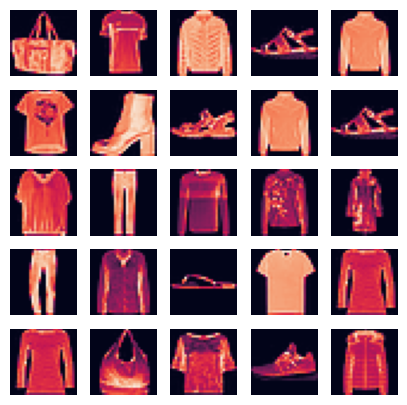

In [32]:
indexes = np.random.randint(0, images.shape[0], size=25)
images_rand = images[indexes]
plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5, 5, i+1)
    image = images_rand[i]
    plt.imshow(image[0])
    plt.axis('off')

plt.show()
plt.close('all')

Przykładowy model sieci nueronowej (bez konwolucji) - czy sądzisz, że to dobre rozwiązanie? 

In [33]:
# Define the network architecture
from torch import nn, optim
import torch.nn.functional as F

model = nn.Sequential(nn.Linear(784, 128),
                      nn.ReLU(),
                      nn.Linear(128, 10),
                      nn.LogSoftmax(dim = 1)
                     )

# Define the loss
criterion = nn.NLLLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr = 0.002)

# Define the epochs
epochs = 30

train_losses, test_losses = [], []

for e in range(epochs):
  running_loss = 0
  for images, labels in trainloader:
    # Flatten Fashion-MNIST images into a 784 long vector
    images = images.view(images.shape[0], -1)
    
    # Training pass
    optimizer.zero_grad()
    
    output = model.forward(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()
    
    running_loss += loss.item()
  else:
    test_loss = 0
    accuracy = 0
    
    # Turn off gradients for validation, saves memory and computation
    with torch.no_grad():
      # Set the model to evaluation mode
      model.eval()
      
      # Validation pass
      for images, labels in testloader:
        images = images.view(images.shape[0], -1)
        log_ps = model(images)
        test_loss += criterion(log_ps, labels)
        
        ps = torch.exp(log_ps)
        top_p, top_class = ps.topk(1, dim = 1)
        equals = top_class == labels.view(*top_class.shape)
        accuracy += torch.mean(equals.type(torch.FloatTensor))
    
    model.train()
    train_losses.append(running_loss/len(trainloader))
    test_losses.append(test_loss/len(testloader))
    
    print("Epoch: {}/{}..".format(e+1, epochs),
          "Training loss: {:.3f}..".format(running_loss/len(trainloader)),
          "Test loss: {:.3f}..".format(test_loss/len(testloader)),
          "Test Accuracy: {:.3f}".format(accuracy/len(testloader)))

Epoch: 1/30.. Training loss: 0.484.. Test loss: 0.424.. Test Accuracy: 0.848
Epoch: 2/30.. Training loss: 0.378.. Test loss: 0.405.. Test Accuracy: 0.852
Epoch: 3/30.. Training loss: 0.342.. Test loss: 0.418.. Test Accuracy: 0.855
Epoch: 4/30.. Training loss: 0.323.. Test loss: 0.388.. Test Accuracy: 0.862
Epoch: 5/30.. Training loss: 0.308.. Test loss: 0.372.. Test Accuracy: 0.866
Epoch: 6/30.. Training loss: 0.294.. Test loss: 0.374.. Test Accuracy: 0.869
Epoch: 7/30.. Training loss: 0.281.. Test loss: 0.373.. Test Accuracy: 0.870
Epoch: 8/30.. Training loss: 0.271.. Test loss: 0.362.. Test Accuracy: 0.876
Epoch: 9/30.. Training loss: 0.262.. Test loss: 0.366.. Test Accuracy: 0.873
Epoch: 10/30.. Training loss: 0.255.. Test loss: 0.354.. Test Accuracy: 0.881
Epoch: 11/30.. Training loss: 0.248.. Test loss: 0.378.. Test Accuracy: 0.875
Epoch: 12/30.. Training loss: 0.241.. Test loss: 0.372.. Test Accuracy: 0.876
Epoch: 13/30.. Training loss: 0.235.. Test loss: 0.394.. Test Accuracy: 0

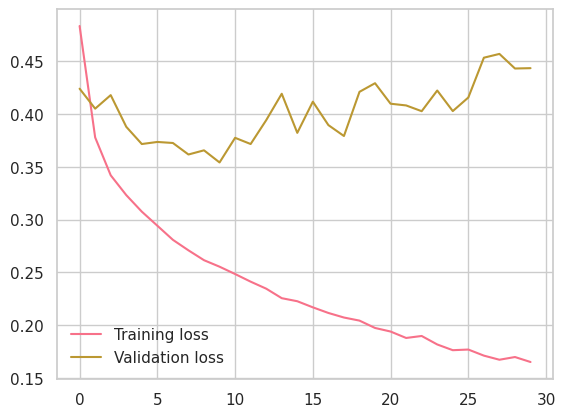

In [34]:
plt.plot(train_losses, label = "Training loss")
plt.plot(test_losses, label = "Validation loss")
plt.legend(frameon = False)

In [35]:
print("My model: \n\n", model, "\n")
print("The state dict keys: \n\n", model.state_dict().keys())

My model: 

 Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
  (3): LogSoftmax(dim=1)
) 

The state dict keys: 

 odict_keys(['0.weight', '0.bias', '2.weight', '2.bias'])


In [36]:
torch.save(model.state_dict(), 'checkpoint.pth')

A jakie inne sieci i warstwy możemy wykorzystać do analizy danych nieustrukturyzowanych? 

> Znajdź odpowiedź na to pytanie w dokumentacji biblioteki PyTorch.

## tekst

In [37]:
import pandas as pd
df_train = pd.read_csv("train.csv")
df_train = df_train.drop("index", axis=1)
print(df_train.head())
print(np.bincount(df_train["label"]))

                                                text  label
0  When we started watching this series on cable,...      1
1  Steve Biko was a black activist who tried to r...      1
2  My short comment for this flick is go pick it ...      1
3  As a serious horror fan, I get that certain ma...      0
4  Robert Cummings, Laraine Day and Jean Muir sta...      1
[17452 17548]


In [38]:
# BoW model  - wektoryzator z sklearn
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(lowercase=True, max_features=10_000, stop_words="english")

cv.fit(df_train["text"])

CountVectorizer(max_features=10000, stop_words='english')

In [41]:
# słownik i nasze zmienne ..
cv.vocabulary_

In [42]:
X_train = cv.transform(df_train["text"])

In [43]:
# to dense matrix
feat_vec = np.array(X_train[0].todense())[0]
print(feat_vec.shape)
np.bincount(feat_vec)

(10000,)


array([9926,   67,    5,    0,    1,    0,    1])

## Obiektowe podejście do modelowania

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Pobieramy prawdziwy zbiór danych o Titanicu
titanic = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
df = titanic.frame

# Wybieramy sensowne cechy
numeric_features = ['age', 'fare']
categorical_features = ['pclass', 'sex', 'embarked']

X = df[numeric_features + categorical_features].copy()
y = df['survived'].astype(int) # Cel: czy przeżył (0 lub 1)

# Celowo dodajemy bezużyteczną kolumnę, aby przetestować Twój transformator!
X['useless_column'] = 'Taka Sama Wartosc'
categorical_features.append('useless_column')

# Podział na zbiór treningowy i testowy
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# ==========================================
# 3. BUDOWA PIPELINE
# ==========================================


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin

# Pipeline dla danych numerycznych
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Pipeline dla danych kategorycznych (wstrzykujemy Twój transformator na początek!)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [4]:
# Łączenie transformatorów
preprocessor = ColumnTransformer(transformers=[
    ("num_trans", numeric_transformer, numeric_features),
    ("cat_trans", categorical_transformer, categorical_features)
])

# Główny pipeline z domyślnym modelem (na start Logistic Regression)
full_pipeline = Pipeline(steps=[
    ("preproc", preprocessor),
    ("model", LogisticRegression())
])

In [6]:
# ==========================================
# 4. TUNING HIPERPARAMETRÓW (GRID SEARCH)
# ==========================================


from sklearn.model_selection import GridSearchCV

# Siatka parametrów uwzględniająca RandomForest, LogisticRegression oraz nasz model losowy
param_grid = [
    # Siatka 1: Random Forest
    {
        "preproc__num_trans__imputer__strategy": ["mean", "median"],
        "model": [RandomForestClassifier(random_state=42)],
        "model__n_estimators": [10, 50, 100],
        "model__max_depth": [None, 5, 10]
    },
    # Siatka 2: Logistic Regression
    {
        "preproc__num_trans__imputer__strategy": ["mean", "median"],
        "model": [LogisticRegression(max_iter=1000)],
        "model__C": [0.1, 1.0, 10.0]
    },
]

# Uruchomienie wyszukiwania
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, verbose=1, n_jobs=-1)
grid_search.fit(X_tr, y_tr)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [RandomForestC...ndom_state=42)], 'model__max_depth': [None, 5, ...], 'model__n_estimators': [10, 50, ...], 'preproc__num_trans__imputer__strategy': ['mean', 'median']}, {'model': [LogisticRegre...max_iter=1000)], 'model__C': [0.1, 1.0, ...], 'preproc__num_trans__imputer__strategy': ['mean', 'median']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``

In [7]:
print("\n" + "="*40)
print("NAJLEPSZE PARAMETRY:")
print("="*40)
for param, val in grid_search.best_params_.items():
    print(f"{param}: {val}")

# Wynik na zbiorze testowym dla najlepszego modelu
best_model_score = grid_search.score(X_test, y_test)


NAJLEPSZE PARAMETRY:
model: RandomForestClassifier(random_state=42)
model__max_depth: 5
model__n_estimators: 100
preproc__num_trans__imputer__strategy: mean


In [9]:
# Twój transformator usuwający kolumny z jedną wartością
class DelOneValueFeature(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.one_value_features = []
        
    def fit(self, X, y=None):
        # Konwersja na DataFrame, jeśli dane wejściowe to NumPy array
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        
        self.one_value_features = [col for col in X.columns if X[col].nunique() == 1]
        return self

    def transform(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        if not self.one_value_features:
            return X
        return X.drop(columns=self.one_value_features)


# Model losowy (Dummy/Random Classifier) w pełni zgodny ze scikit-learn
class RandomClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, random_state=None):
        self.random_state = random_state
        self.classes_ = None

    def fit(self, X, y):
        # Zapamiętujemy unikalne klasy z wektora docelowego
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        np.random.seed(self.random_state)
        # Losujemy klasy dla każdego wiersza w X
        return np.random.choice(self.classes_, size=len(X))

    def predict_proba(self, X):
        np.random.seed(self.random_state)
        # Losujemy prawdopodobieństwa, które sumują się do 1
        raw_probs = np.random.rand(len(X), len(self.classes_))
        return raw_probs / raw_probs.sum(axis=1, keepdims=True)

In [10]:
# Pipeline dla danych kategorycznych (wstrzykujemy Twój transformator na początek!)
categorical_transformer = Pipeline(steps=[
    ("remover", DelOneValueFeature()),  # Usunie 'useless_column' przed OneHotEncoderem!
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [11]:
# Siatka parametrów uwzględniająca RandomForest, LogisticRegression oraz nasz model losowy
param_grid = [
    # Siatka 1: Random Forest
    {
        "preproc__num_trans__imputer__strategy": ["mean", "median"],
        "model": [RandomForestClassifier(random_state=42)],
        "model__n_estimators": [10, 50, 100],
        "model__max_depth": [None, 5, 10]
    },
    # Siatka 2: Logistic Regression
    {
        "preproc__num_trans__imputer__strategy": ["mean", "median"],
        "model": [LogisticRegression(max_iter=1000)],
        "model__C": [0.1, 1.0, 10.0]
    },
    # Siatka 3: Nasz własny model losowy (Baseline do porównania)
    {
        "model": [RandomClassifier(random_state=42)]
    }
]

# Uruchomienie wyszukiwania
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, verbose=1, n_jobs=-1)
grid_search.fit(X_tr, y_tr)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [RandomForestC...ndom_state=42)], 'model__max_depth': [None, 5, ...], 'model__n_estimators': [10, 50, ...], 'preproc__num_trans__imputer__strategy': ['mean', 'median']}, {'model': [LogisticRegre...max_iter=1000)], 'model__C': [0.1, 1.0, ...], 'preproc__num_trans__imputer__strategy': ['mean', 'median']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [12]:
print("\n" + "="*40)
print("NAJLEPSZE PARAMETRY:")
print("="*40)
for param, val in grid_search.best_params_.items():
    print(f"{param}: {val}")

# Wynik na zbiorze testowym dla najlepszego modelu
best_model_score = grid_search.score(X_test, y_test)

# Sprawdźmy jak poradziłby sobie sam model losowy dla porównania
random_baseline = RandomClassifier(random_state=42)
random_baseline.fit(X_tr, y_tr)
random_score = random_baseline.score(X_test, y_test)

print("\n" + "="*40)
print("PORÓWNANIE DOKŁADNOŚCI (ACCURACY):")
print("="*40)
print(f"Nasz najlepszy model z GridSearch: {best_model_score:.4f}")
print(f"Model stricte losowy (Baseline):  {random_score:.4f}")


NAJLEPSZE PARAMETRY:
model: RandomForestClassifier(random_state=42)
model__max_depth: 5
model__n_estimators: 100
preproc__num_trans__imputer__strategy: mean

PORÓWNANIE DOKŁADNOŚCI (ACCURACY):
Nasz najlepszy model z GridSearch: 0.7634
Model stricte losowy (Baseline):  0.4847
